<a href="https://colab.research.google.com/github/kjfcvx12/Colab/blob/main/20260417%2001.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from torchvision import datasets
import torchvision.transforms as transforms
# 데이터셋을 무작위로 샘플링할때 쓰려고(train/test)
from torch.utils.data.sampler import SubsetRandomSampler


In [2]:
# cuda : gpu 쓰기위한 도구(플랫폼)
device=torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

In [3]:
# root=데이터저장경로
# MNIST 이미지 (1,28,28) -> ToTensor(텐서로 변환) (0~1)
train_data=datasets.MNIST(root="./data", train=True, download=True, transform=transforms.ToTensor())
test_data=datasets.MNIST(root="./data", train=False, download=True, transform=transforms.ToTensor())

100%|██████████| 9.91M/9.91M [00:00<00:00, 57.8MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.77MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 14.3MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 10.9MB/s]


In [4]:
print(train_data)
print(test_data)

Dataset MNIST
    Number of datapoints: 60000
    Root location: ./data
    Split: Train
    StandardTransform
Transform: ToTensor()
Dataset MNIST
    Number of datapoints: 10000
    Root location: ./data
    Split: Test
    StandardTransform
Transform: ToTensor()


In [5]:
train_data[0][0].shape

torch.Size([1, 28, 28])

In [6]:
print(train_data[0]) # (image, label)
print(train_data[0][0]) # image
print(train_data[0][1]) # label

(tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000

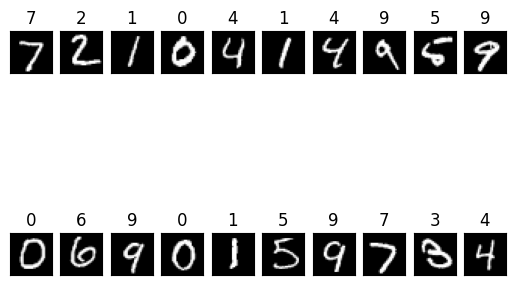

In [7]:
# i : 인덱스
# (x,y) => (image, label)
for i, (x,y) in enumerate(test_data):
  if i>19:
    break

  plt.subplot(2,10,i+1)
  plt.imshow(x.view(28,28), cmap="gray")
  plt.title(y)
  plt.xticks([])
  plt.yticks([])
plt.show()

In [8]:
in_data=list(range(60000)) # [0,1, ..... 59999]
np.random.shuffle(in_data) # 번호표를 무작위로 섞어놓음
split_data=int(np.floor(0.2*60000)) # 12000개는 train-validation용으로 설정 48000개는 train용

# train_index : 12001번째부터 마지막까지(48000개) - 학습용
# valid_index : 처음부터 12000번째까지(12000개) - 검증용
train_index, valid_index=in_data[split_data:], in_data[:split_data]

In [9]:
# 주어진 인덱스 리스트에서 무작위 순서로 데이터 샘플링하려고
train_sample=SubsetRandomSampler(train_index)
valid_sample=SubsetRandomSampler(valid_index)

In [10]:
from torch.utils.data import DataLoader

In [11]:
# SubsetRandomSampler - DataLoader
# DataLoader 가 다음 값 요청하면 샘플러가 인덱스 하나를 무작위로 던져주는 구조(호환됨)
train_loader=DataLoader(train_data, batch_size=128, sampler=train_sample)
vaild_loader=DataLoader(train_data, batch_size=128, sampler=valid_sample)
# 60000개를 무작위로 섞은 후 80% 학습 20% 검즘용으로 나눔

test_loader=DataLoader(test_data, batch_size=128, shuffle=False) # 10000개

In [12]:
from torch.autograd import forward_ad
# 레이어 정의
class Mnist1(nn.Module):
  def __init__(self, in_dim, hidden_dim, out_dim):
    super().__init__()
    self.f1=nn.Linear(in_dim, hidden_dim) # 입력 -> 은닉1
    self.f2=nn.Linear(hidden_dim, hidden_dim) # 은닉1 -> 은닉2
    self.f3=nn.Linear(hidden_dim, out_dim) # 은닉2 -> 출력
    self.dropout=nn.Dropout(0.2) # 과적합 방지용 드롭아웃 0.2 => 20% 노드는 무작위로 비활성화 된다
    self.relu=nn.ReLU()

    # f1 -> relu -> dropout -> f2 -> relu -> dropout -> f3 -> 출력층 -> softmax -> 확률분포에 따라 예측
    # 순전파
  def forward(self, x):
    x=self.relu(self.f1(x))
    x=self.dropout(x)
    x=self.relu(self.f2(x))
    x=self.dropout(x)
    # 최종 클래스 확률 계산 안정적으로 하기위해 dropout 안함
    out=self.f3(x)
    return out

In [13]:
in_dim=28*28 # 784개
hidden_dim=128
out_dim=10 # 10개 숫자

In [14]:
model=Mnist1(in_dim, hidden_dim, out_dim)
model

Mnist1(
  (f1): Linear(in_features=784, out_features=128, bias=True)
  (f2): Linear(in_features=128, out_features=128, bias=True)
  (f3): Linear(in_features=128, out_features=10, bias=True)
  (dropout): Dropout(p=0.2, inplace=False)
  (relu): ReLU()
)

In [17]:
# 1장의 이미지를 모델에 넣어 출력값 계산 -> torch.Size([1, 28, 28]) -> __call__ -> forward
for image, label in train_loader:
  image_trans=model(image[0].view(-1, 28*28))
  break

print(image_trans) # 0~9까지 수에서 0일 확률을 -0.0287 , 1일 확률은 -0.0781
print(image_trans.shape)
# 텐서에서 계산(gradient)없이 값만 가져올때
print(image_trans[0].data)
prediction=torch.argmax(image_trans, dim=1)
print(prediction)


tensor([[-0.0332, -0.0095,  0.0339,  0.0810, -0.0436, -0.1113, -0.1655,  0.0383,
          0.0827, -0.0633]], grad_fn=<AddmmBackward0>)
torch.Size([1, 10])
tensor([-0.0332, -0.0095,  0.0339,  0.0810, -0.0436, -0.1113, -0.1655,  0.0383,
         0.0827, -0.0633])
tensor([8])


In [18]:
# 다중 분류에서 가장 많이 쓰이는 손실함수
crossloss=nn.CrossEntropyLoss()
# 모델을 cpu로 올린 후에 입력데이터도 cpu로 이동시킴
model.to(device)

Mnist1(
  (f1): Linear(in_features=784, out_features=128, bias=True)
  (f2): Linear(in_features=128, out_features=128, bias=True)
  (f3): Linear(in_features=128, out_features=10, bias=True)
  (dropout): Dropout(p=0.2, inplace=False)
  (relu): ReLU()
)